## Импорт и тренировочные модули

In [1]:
import torch
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from utils.visualization_utils import compare_train_models, compare_test_models, plot_confusion_matrix, visualize_first_layer_activations, visualize_feature_maps
from models.fc_models import get_fc_mnist_loaders, get_fc_cifar_loaders
from models.fc_models import create_model_from_config
from utils.training_utils import count_parameters, train_fc_model, train_cnn_model
from models.cnn_models import SimpleCNN, CNNWithResidual, CIFARCNN, get_cnn_mnist_loaders, get_cnn_cifar_loaders, \
    CNNWithResidualCombo, CNNWithResidual5x5, CNNWithResidual7x7, CNN4ConvLayers, CNN6ConvLayers

In [3]:
def training_fc(path:str, name:str, train_loader, test_loader, epochs, device=torch.device('cuda:0')):
    model = create_model_from_config(path)
    model.to(device)
    print(f"Model: {name}")
    print(f"Model parameters: {count_parameters(model)}")
    history = train_fc_model(model, train_loader, test_loader, False, epochs=epochs, device=str(device))
    return history

def training_cnn(name, train_loader, test_loader, epochs, device=torch.device('cuda:0')):
    model = get_model_type(name)
    print(f"Model: {name}")
    print(f"Model parameters: {count_parameters(model)}")
    history = train_cnn_model(model, train_loader, test_loader, epochs=epochs, device=str(device))
    return history

def get_model_type(name, device=torch.device('cuda:0')):
    match name:
        case "CNNWithResidual":
            return CNNWithResidual(input_channels=1, num_classes=10).to(device)
        case 'CNN window 3x3':
            return CNNWithResidual(input_channels=1, num_classes=10).to(device)
        case "CIFARCNN":
            return CIFARCNN(num_classes=10).to(device)
        case "CNNWithResidualCombo":
            return CNNWithResidualCombo(input_channels=1, num_classes=10).to(device)
        case "CNN window 5x5":
            return CNNWithResidual5x5(input_channels=1, num_classes=10).to(device)
        case "CNN window 7x7":
            return CNNWithResidual7x7(input_channels=1, num_classes=10).to(device)
        case "CNN 4 Conv":
            return CNN4ConvLayers(input_channels=1, num_classes=10).to(device)
        case "CNN 6 Conv":
            return CNN6ConvLayers(input_channels=1, num_classes=10).to(device)
    return SimpleCNN(input_channels=1, num_classes=10).to(device)

def show_first_layers(name, input_image_tensor):
    model = get_model_type(name)
    print("\nВизуализация активаций первого слоя для " + name)
    visualize_first_layer_activations(model, input_image_tensor, model_name=name)

def show_feature_maps(name, input_image_tensor, layers):
    model = get_model_type(name)
    visualize_feature_maps(model, input_image_tensor, layers, model_name=name)

train_cnn_mnist, test_cnn_mnist = get_cnn_mnist_loaders(batch_size=1024)
train_fc_mnist, test_fc_mnist = get_fc_mnist_loaders(batch_size=1024)
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
device = torch.device('cuda:0')
mnist_dataset = MNIST(root='./data', train=False, download=True, transform=transform)
(image, label) = mnist_dataset[9]
input_image_tensor = image.unsqueeze(0).to(device)

## 1.1 Сравнение на MNIST


Model: FC neural network
Model parameters: 568970


100%|██████████| 10/10 [00:01<00:00,  6.68it/s]


Epoch 1/5:
Train Loss: 0.4788, Train Acc: 0.8854
Test Loss: 0.1448, Test Acc: 0.9543
--------------------------------------------------


100%|██████████| 10/10 [00:01<00:00,  6.38it/s]


Epoch 2/5:
Train Loss: 0.1197, Train Acc: 0.9640
Test Loss: 0.0971, Test Acc: 0.9693
--------------------------------------------------


...

Epoch 3/5:
Train Loss: 0.0413, Train Acc: 0.9885
Test Loss: 0.0394, Test Acc: 0.9873
--------------------------------------------------


100%|██████████| 10/10 [00:01<00:00,  5.28it/s]


Epoch 4/5:
Train Loss: 0.0313, Train Acc: 0.9913
Test Loss: 0.0335, Test Acc: 0.9905
--------------------------------------------------


100%|██████████| 10/10 [00:01<00:00,  5.21it/s]


Epoch 5/5:
Train Loss: 0.0265, Train Acc: 0.9925
Test Loss: 0.0377, Test Acc: 0.9872
--------------------------------------------------


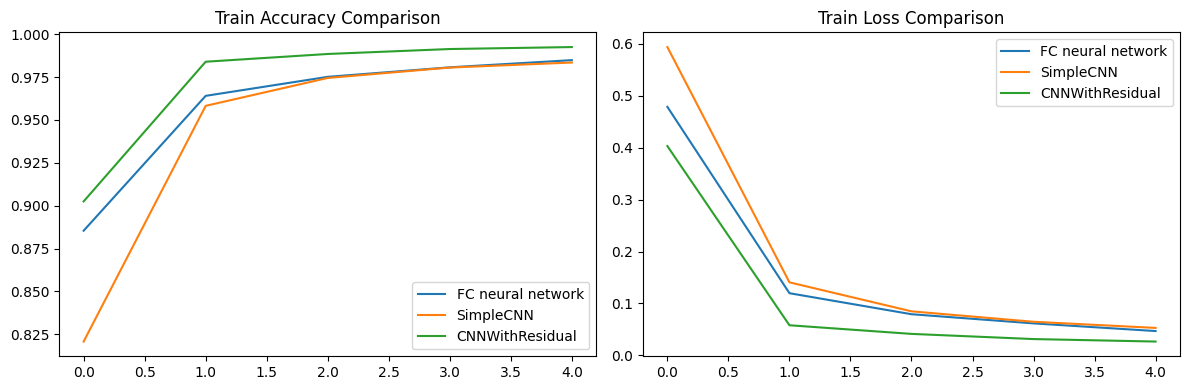

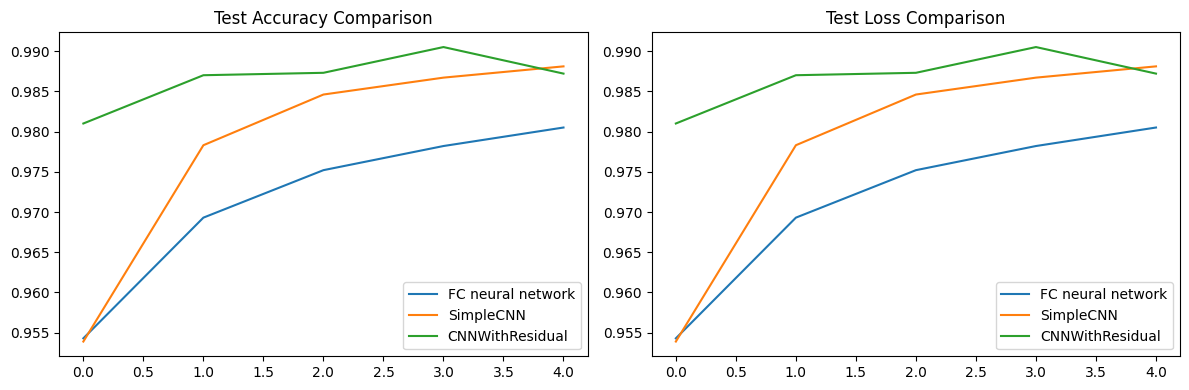

In [3]:
history_fc = training_fc('fc_nn.json', 'FC neural network', train_fc_mnist, test_fc_mnist, 5)
history_cnn = training_cnn('SimpleCNN', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))
history_cnn_residual = training_cnn('CNNWithResidual', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))

history = [history_fc, history_cnn, history_cnn_residual]
names = ['FC neural network', 'SimpleCNN', 'CNNWithResidual']
compare_train_models(history, names )
compare_test_models(history, names)

## 1.2 Сравнение на CIFAR-10

In [12]:
train_fc_cifar, test_fc_cifar = get_fc_cifar_loaders(batch_size=512)
train_cnn_cifar, test_cnn_cifar = get_cnn_cifar_loaders(batch_size=512)

#history_fc = training_fc('fc_deep.json', 'FC neural network', test_fc_cifar, test_fc_cifar, 1)
history_cnn = training_cnn('CIFARCNN', train_cnn_cifar, test_cnn_cifar, 1, device=torch.device('cuda:0'))
history_cnn_reg = training_cnn('CIFARCNN', train_cnn_cifar, test_cnn_cifar, 1, device=torch.device('cuda:0'))

history = [history_fc, history_cnn, history_cnn_reg]
names = ['FC neural network', 'CNNWithResidual', 'CIFARCNN']

compare_train_models(history, names)
compare_test_models(history, names)

'''plot_confusion_matrix(
        all_true_labels=history_fc['final_test_true_labels'],
        all_preds=history_fc['final_test_preds'],
        num_classes=10,
        model_name='FC neural network'
    )'''
plot_confusion_matrix(
        all_true_labels=history_fc['final_test_true_labels'],
        all_preds=history_fc['final_test_preds'],
        num_classes=10,
        model_name='CNNWithResidual'
    )
plot_confusion_matrix(
        all_true_labels=history_fc['final_test_true_labels'],
        all_preds=history_fc['final_test_preds'],
        num_classes=10,
        model_name='CIFARCNN'
    )



Model: FC neural network
Model parameters: 578730


  0%|          | 0/20 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (512x3072 and 784x512)

## 2.1 Влияние размера ядра свертки

Model: CNN window 3x3
Model parameters: 160906


100%|██████████| 10/10 [00:01<00:00,  5.36it/s]


Epoch 1/5:
Train Loss: 0.4328, Train Acc: 0.8974
Test Loss: 0.0723, Test Acc: 0.9809
--------------------------------------------------


100%|██████████| 10/10 [00:01<00:00,  5.34it/s]


Epoch 2/5:
Train Loss: 0.0579, Train Acc: 0.9842
Test Loss: 0.0545, Test Acc: 0.9822
--------------------------------------------------


...

Epoch 3/5:
Train Loss: 0.0409, Train Acc: 0.9885
Test Loss: 0.0385, Test Acc: 0.9861
--------------------------------------------------


100%|██████████| 10/10 [00:01<00:00,  5.08it/s]


Epoch 4/5:
Train Loss: 0.0324, Train Acc: 0.9905
Test Loss: 0.0342, Test Acc: 0.9884
--------------------------------------------------


100%|██████████| 10/10 [00:01<00:00,  5.39it/s]


Epoch 5/5:
Train Loss: 0.0272, Train Acc: 0.9920
Test Loss: 0.0227, Test Acc: 0.9932
--------------------------------------------------


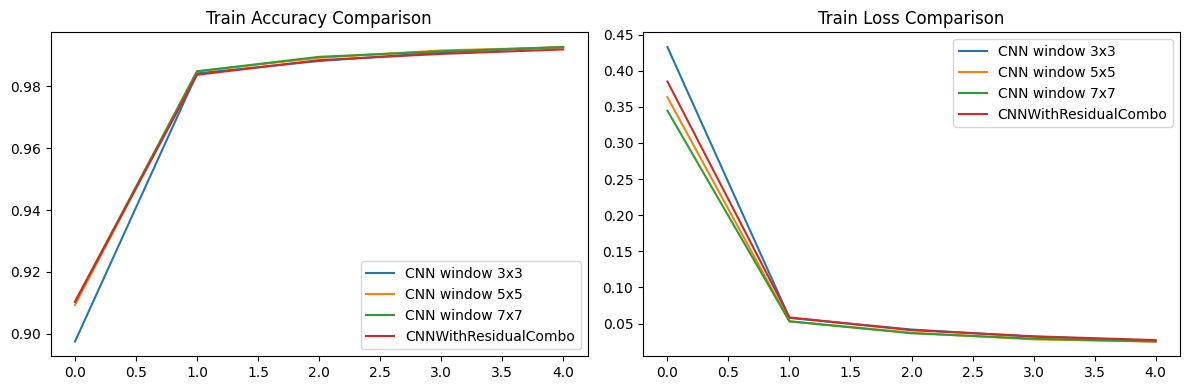

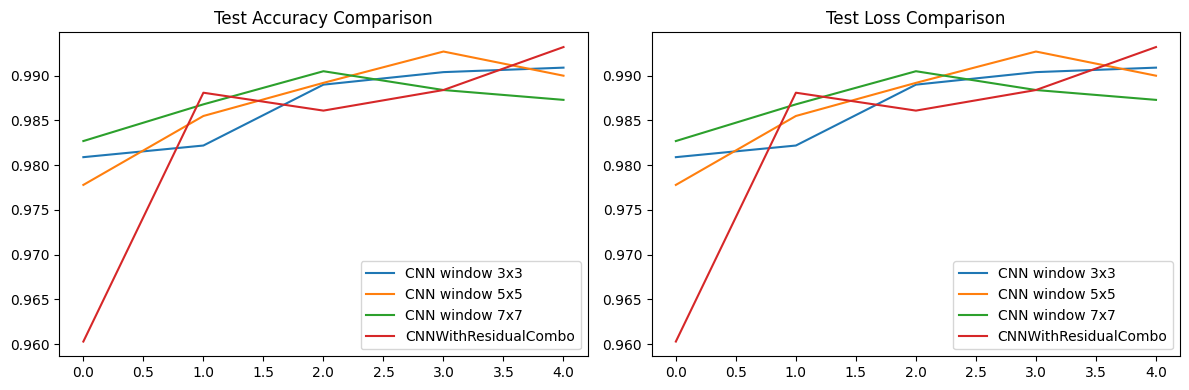


Визуализация активаций первого слоя для CNN window 3x3


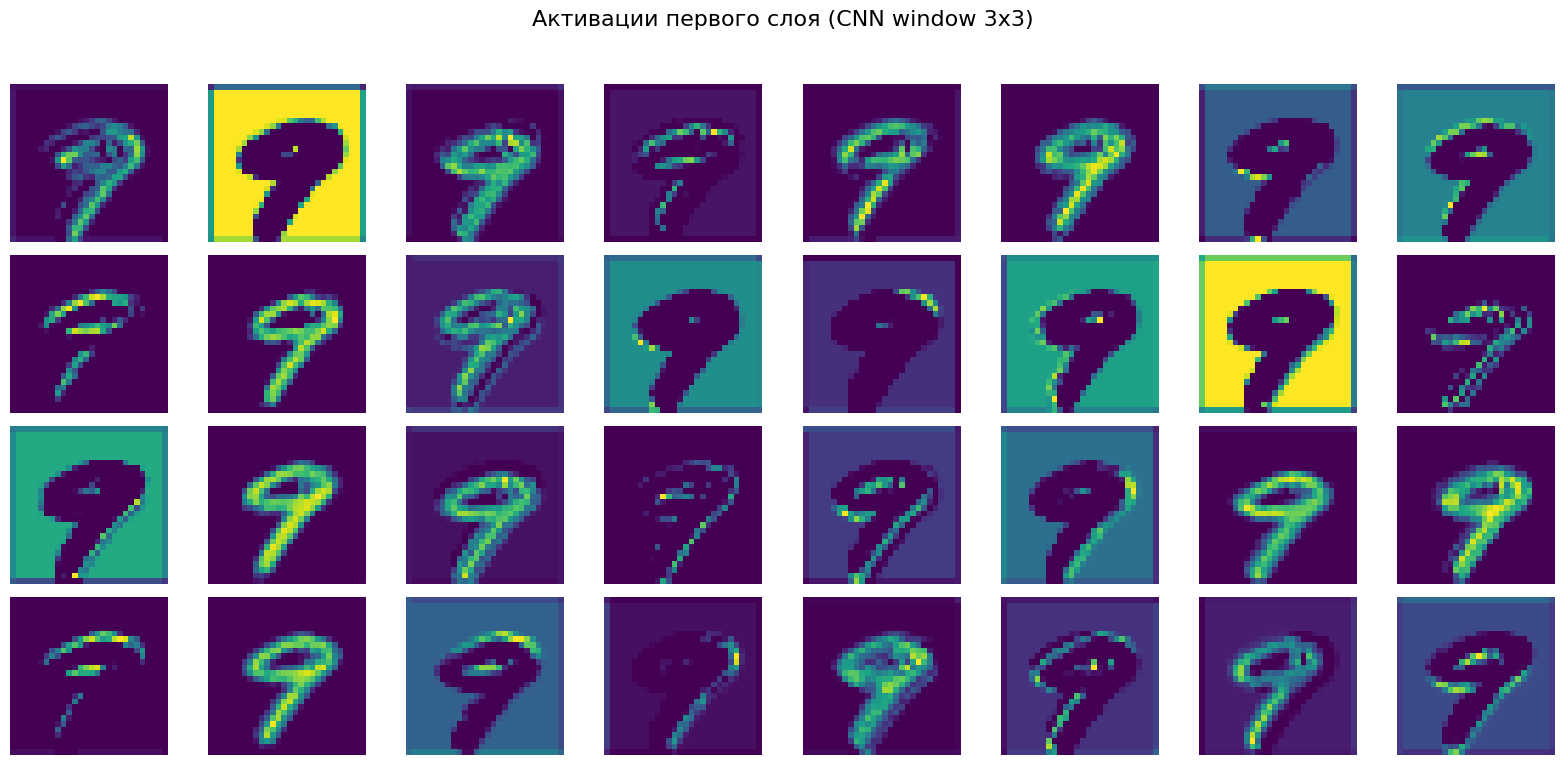


Визуализация активаций первого слоя для CNN window 5x5


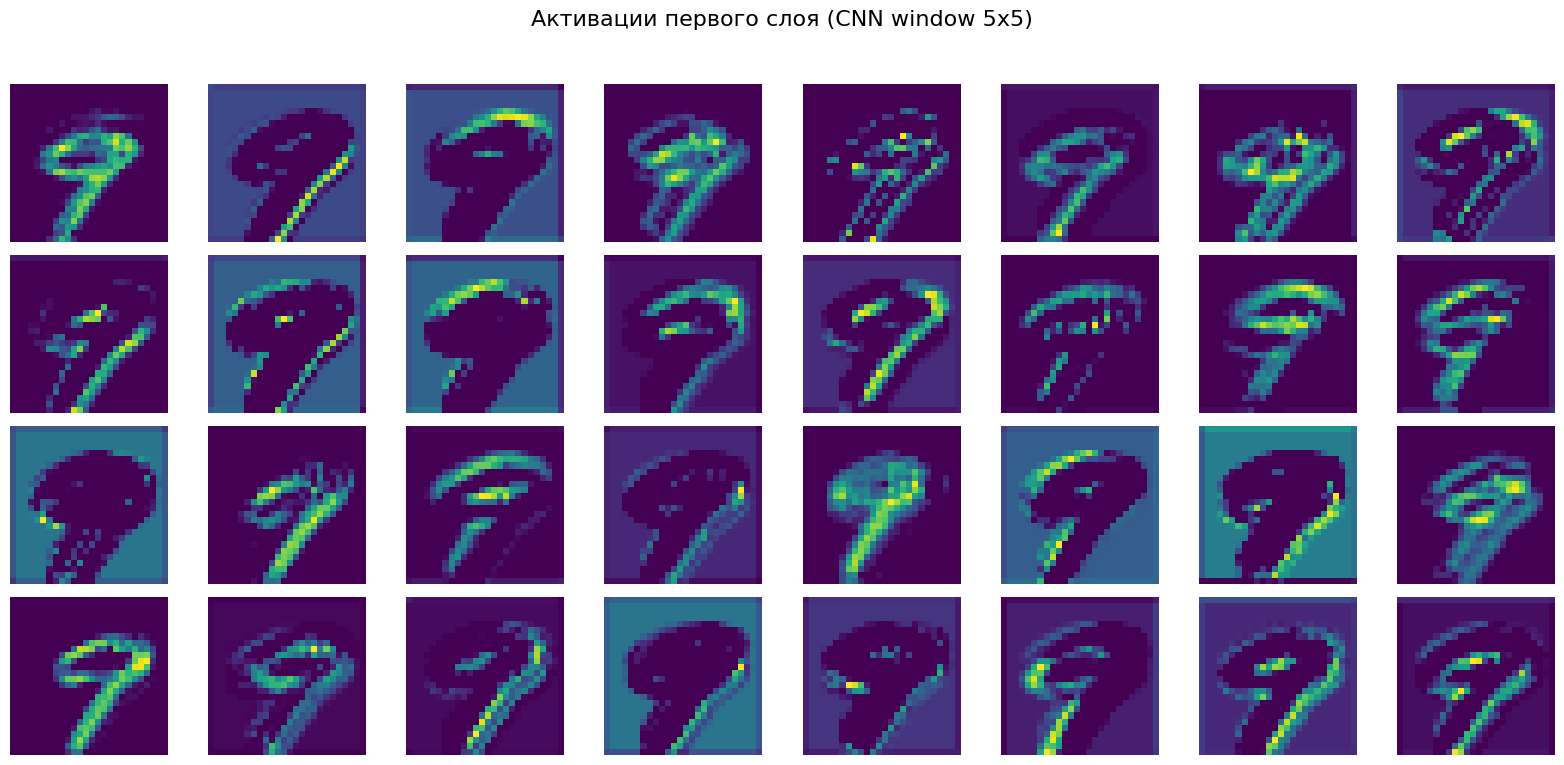


Визуализация активаций первого слоя для CNN window 7x7


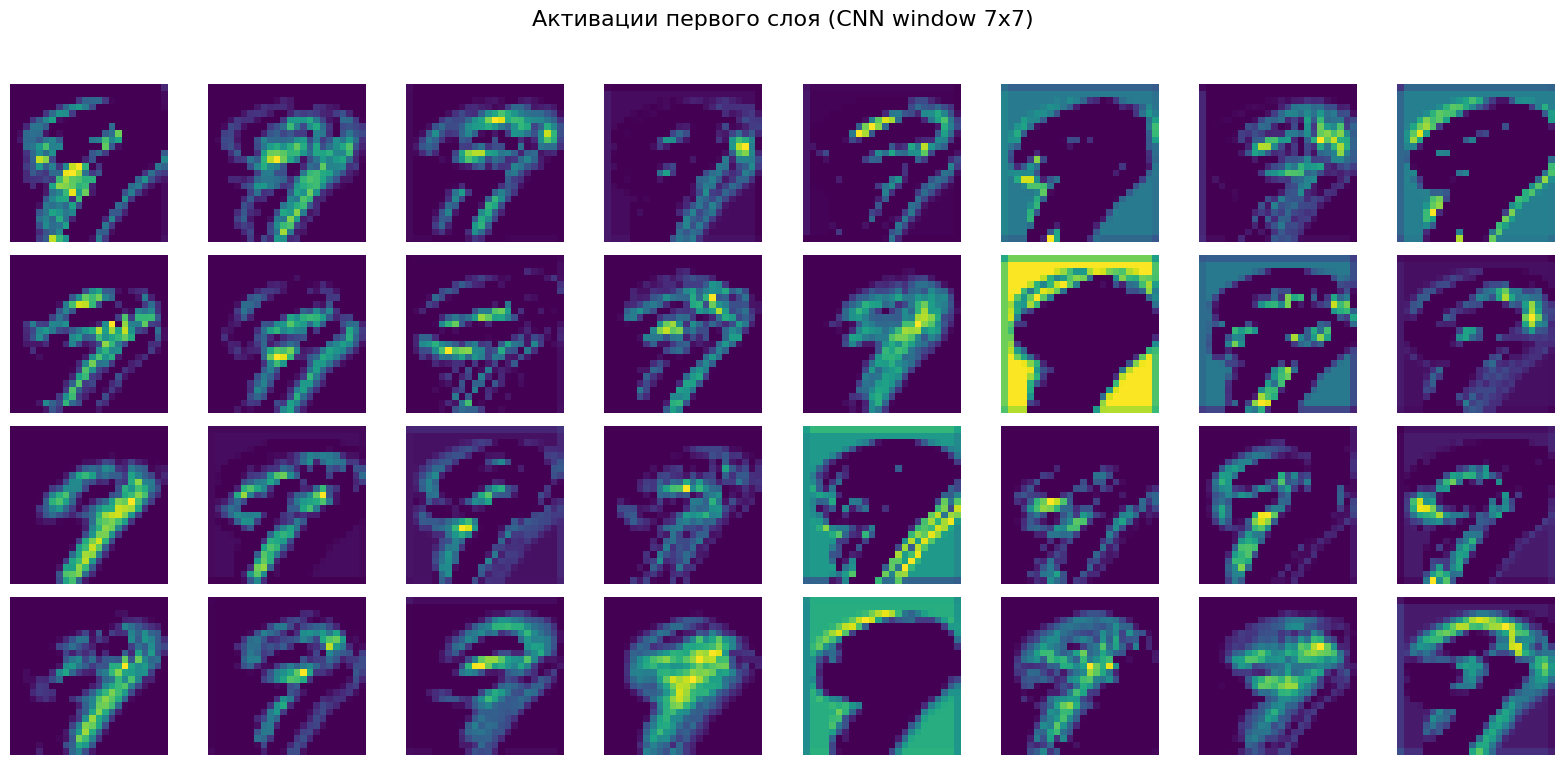


Визуализация активаций первого слоя для CNNWithResidualCombo


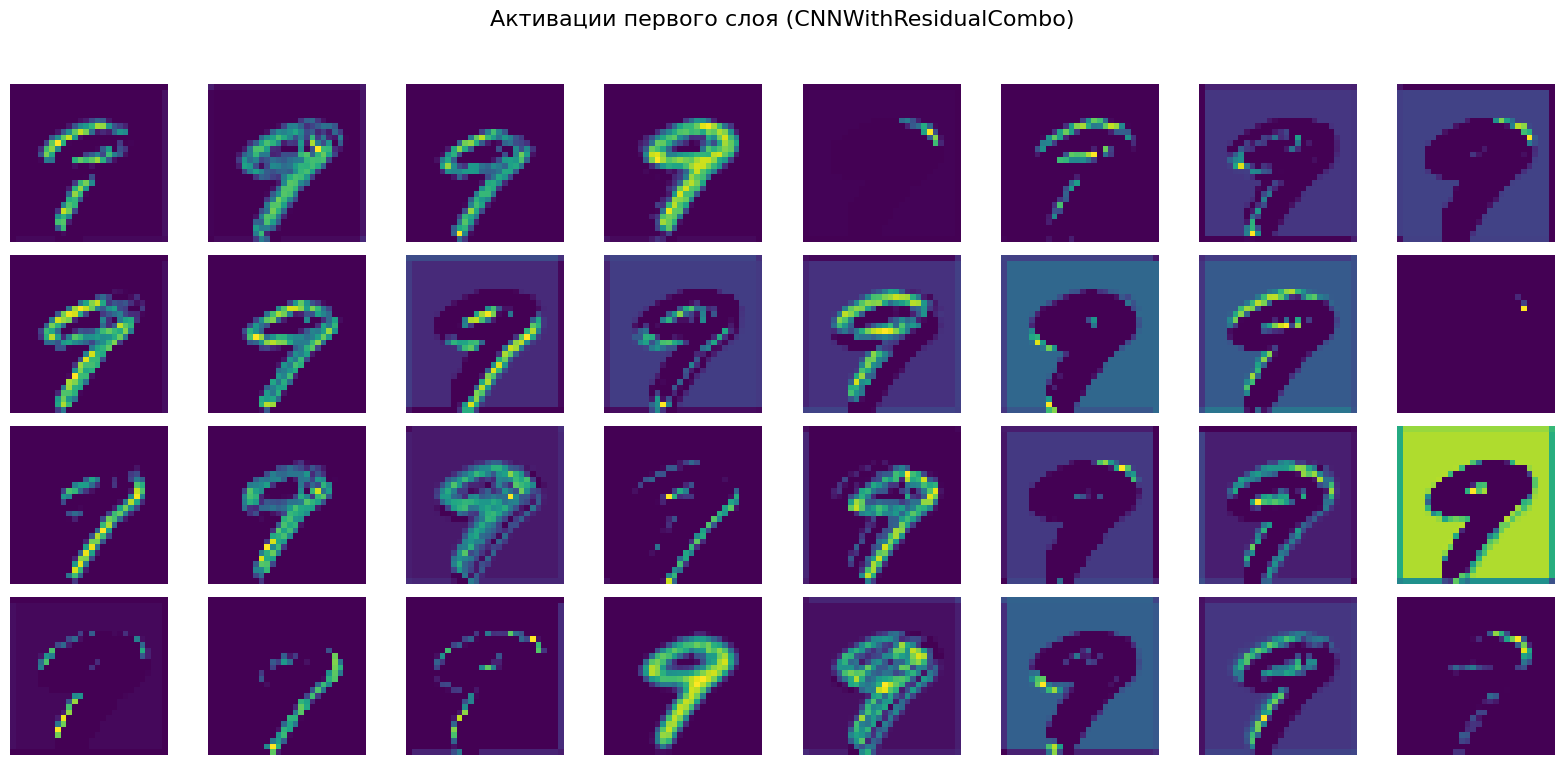

In [5]:
history_cnn3 = training_cnn('CNN window 3x3', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))
history_cnn5 = training_cnn('CNN window 5x5', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))
history_cnn7 = training_cnn('CNN window 7x7', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))
history_cnn3_1 = training_cnn('CNNWithResidualCombo', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))

history = [history_cnn3, history_cnn5, history_cnn7, history_cnn3_1]
names = ['CNN window 3x3', 'CNN window 5x5', 'CNN window 7x7', 'CNNWithResidualCombo']
compare_train_models(history, names)
compare_test_models(history, names)

# Визуализируем первый слой
for name in names:
    show_first_layers(name, input_image_tensor)

## 2.2 Влияние глубины

Model: SimpleCNN
Model parameters: 421642


100%|██████████| 10/10 [00:01<00:00,  6.01it/s]


Epoch 1/5:
Train Loss: 0.5889, Train Acc: 0.8218
Test Loss: 0.1386, Test Acc: 0.9579
--------------------------------------------------


100%|██████████| 10/10 [00:01<00:00,  6.08it/s]


Epoch 2/5:
Train Loss: 0.1355, Train Acc: 0.9593
Test Loss: 0.0731, Test Acc: 0.9763
--------------------------------------------------


...

Epoch 3/5:
Train Loss: 0.0415, Train Acc: 0.9885
Test Loss: 0.0388, Test Acc: 0.9894
--------------------------------------------------


100%|██████████| 59/59 [00:12<00:00,  4.70it/s]


Epoch 4/5:
Train Loss: 0.0329, Train Acc: 0.9906
Test Loss: 0.0389, Test Acc: 0.9879
--------------------------------------------------


100%|██████████| 59/59 [00:12<00:00,  4.66it/s]


Epoch 5/5:
Train Loss: 0.0280, Train Acc: 0.9919
Test Loss: 0.0232, Test Acc: 0.9931
--------------------------------------------------


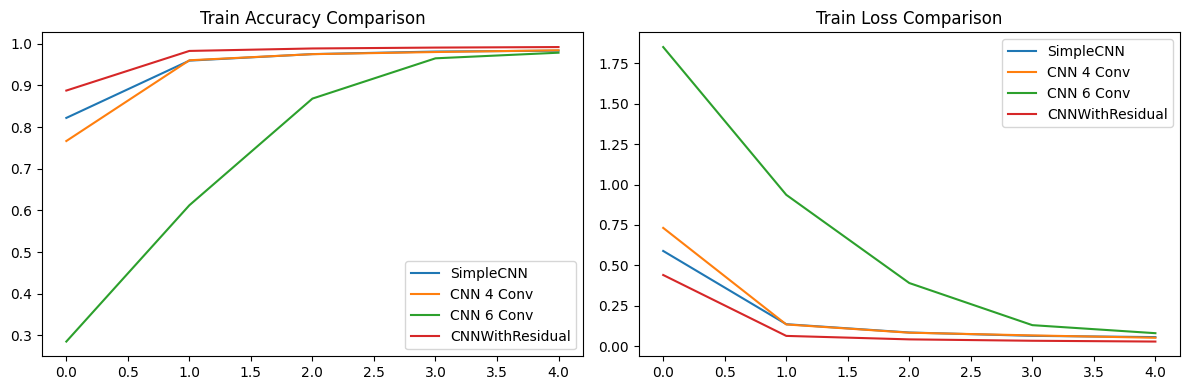

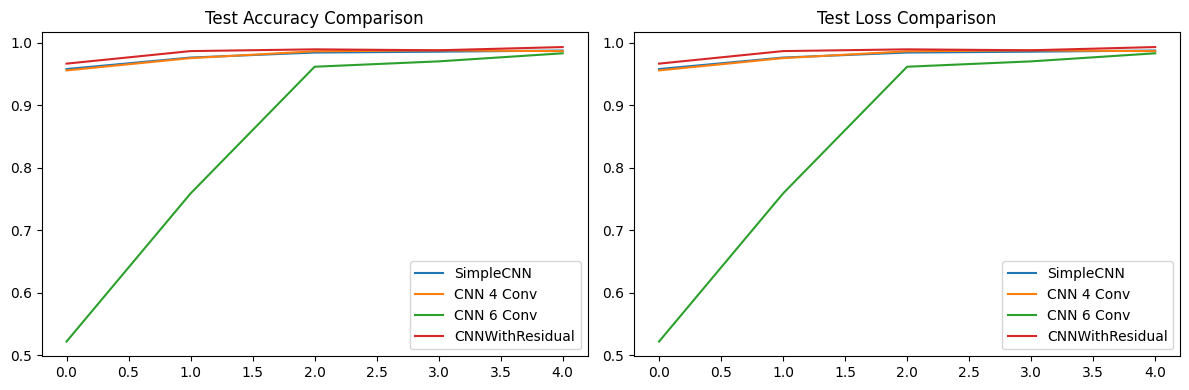

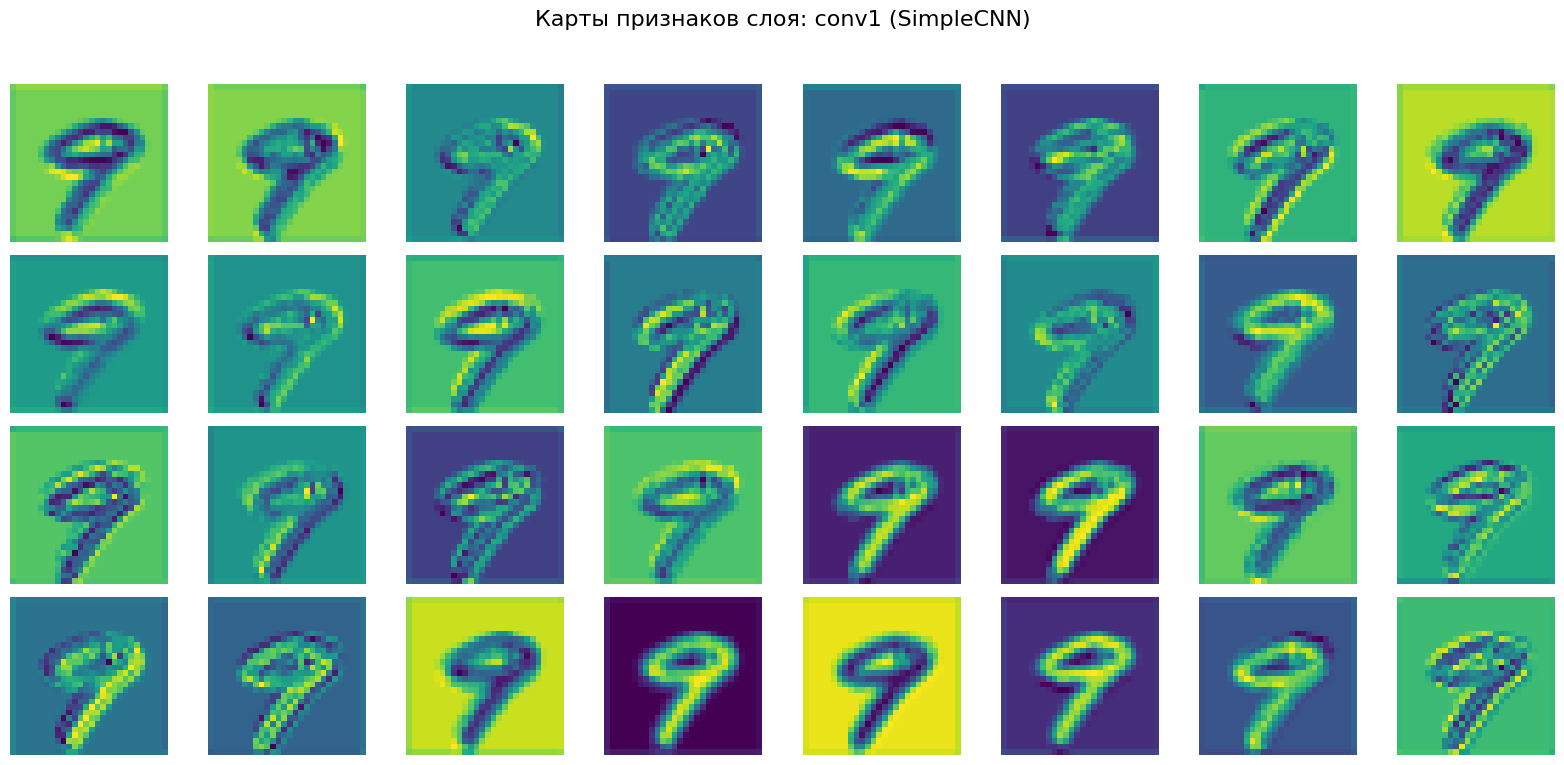

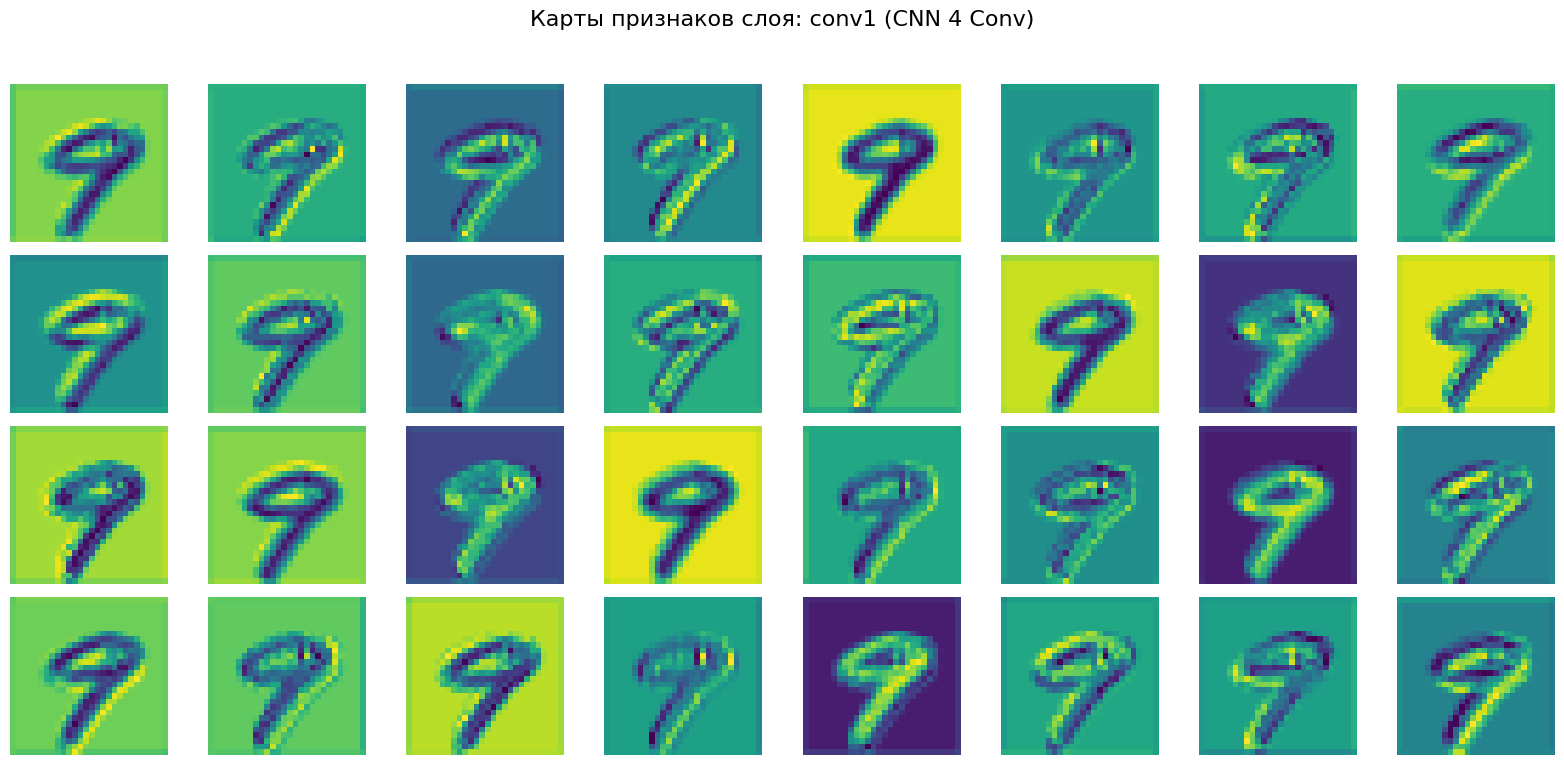

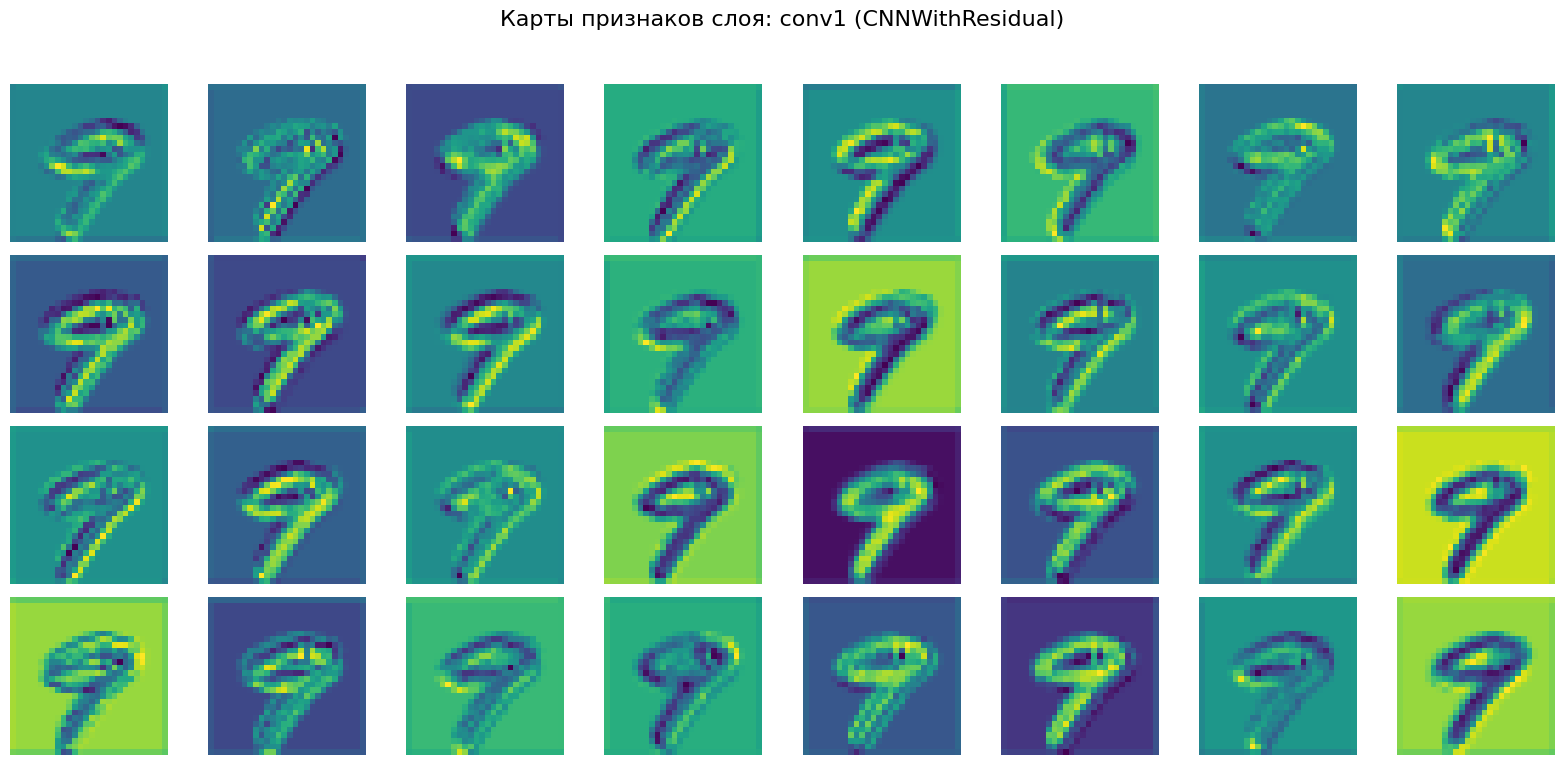

In [14]:
train_cnn_mnist, test_cnn_mnist = get_cnn_mnist_loaders(batch_size=1024)
models_layers = []

history_cnn_2conv = training_cnn('SimpleCNN', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))
history_cnn_4conv = training_cnn('CNN 4 Conv', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))
history_cnn_6conv = training_cnn('CNN 6 Conv', train_cnn_mnist, test_cnn_mnist, 5, device=torch.device('cuda:0'))
history_cnn_residual = training_cnn('CNNWithResidual', train_cnn_mnist, train_cnn_mnist, 5, device=torch.device('cuda:0'))

history = [history_cnn_2conv, history_cnn_4conv, history_cnn_6conv, history_cnn_residual]
names = ['SimpleCNN', 'CNN 4 Conv', 'CNN 6 Conv', 'CNNWithResidual']
compare_train_models(history, names)
compare_test_models(history, names)

for i in range(len(names)):
    show_feature_maps(names[i], input_image_tensor, ['conv1'])

## 3.1 Реализация кастомных слоев

## 3.2 Эксперименты с Residual блоками